In [1]:
#importing library
import pandas as pd

In [7]:
#loading dataset
rawdata = pd.read_csv("netflix_titles.csv")
#understanding data
print(rawdata.head(5))
print(rawdata.info())
print(rawdata.shape)


  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [3]:
#cleaning dataset
df = rawdata.copy()
df.isnull().sum()
df.fillna("Unknown")


#Handling country column
df["country"] = df["country"].str.split(",")
df = df.explode("country")
df["country"] = df["country"].str.strip()

#Handling date_added column
df["date_added"] = df["date_added"].str.strip()
df["date_added"] = pd.to_datetime(df["date_added"])
#Extracting year from date_added
df["year_added"] = df["date_added"].dt.year

#Handling listed_in column
df["listed_in"] = df["listed_in"].str.split(",")
df = df.explode("listed_in")
df["listed_in"] = df["listed_in"].str.strip()

#Handling duration column
df["duration"] = df["duration"].str.split(" ")
#Extracting numerical value
df["duration_num"] = df["duration"].str[0]







In [8]:
#Analysis
#Proportion of Movie and TV Shows
print(df.drop_duplicates("show_id")["type"].value_counts())

#Countries contributing most
print(df.drop_duplicates("show_id")["country"].value_counts())

#Library growth by year
print(df.drop_duplicates("show_id")["year_added"].value_counts().sort_index())

#Genre domination
print(df.drop_duplicates("show_id")["listed_in"].value_counts())

#Ratings
print(df.drop_duplicates("show_id")["rating"].value_counts())

#Duration
print(df.drop_duplicates("show_id")["duration_num"].value_counts())





type
Movie      6131
TV Show    2676
Name: count, dtype: int64
country
United States     3211
India             1008
United Kingdom     628
Canada             271
Japan              259
                  ... 
Namibia              1
Senegal              1
Luxembourg           1
Syria                1
Somalia              1
Name: count, Length: 86, dtype: int64
year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64
listed_in
Dramas                          1600
Comedies                        1210
Action & Adventure               859
Documentaries                    829
International TV Shows           774
Children & Family Movies         605
Crime TV Shows                   399
Kids' TV                         388
Stand-Up Comedy                  334
Horror Movies                    275
British TV 

<Axes: xlabel='duration_num'>

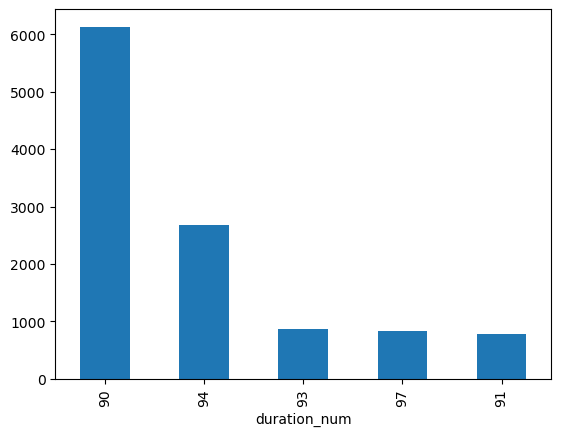

In [11]:
#Visualisation
#Proportion of Movie vs TV Show
df.drop_duplicates("show_id")["type"].value_counts().plot(kind = "bar")
#Country wise titles
country_plot = df.drop_duplicates("show_id")["country"].value_counts()
country_plot[0:5].plot(kind = "bar")
#Library growth
df.drop_duplicates("show_id")["year_added"].value_counts().sort_index().plot()
#Genre Domination
df.drop_duplicates("show_id")["listed_in"].value_counts()[0:5].plot(kind = "bar")
#Ratings
df.drop_duplicates("show_id")["rating"].value_counts()[0:5].plot(kind = "bar")
#Duration_TV_SHOW
df.drop_duplicates("show_id")["duration_num"].value_counts()[0:3].plot(kind = "bar")
#Duration_MOVIE
df.drop_duplicates("show_id")["duration_num"].value_counts()[3:8].plot(kind = "bar")

In [6]:
#CONCLUSION
#1]Movie titles are 6131 and TV Shows are 2676.
#2]Titles contributed by United states : 3211
#                        India         : 1008
#                       United Kingdom : 628
#3]Netflix experienced rapid growth in content additions after 2016, indicating a major expansion of the platform’s content library.
#4]Most titles are listed in Dramas, Comedies, Action & Adventure, Documentries etc.
#5]Most common audience ratings are TV-MA and TV-14.
#6]Most TV Shows have only 1 season and most movies are between 90 and 120 minutes in duration.


listed_in
Dramas                          1600
Comedies                        1210
Action & Adventure               859
Documentaries                    829
International TV Shows           774
Children & Family Movies         605
Crime TV Shows                   399
Kids' TV                         388
Stand-Up Comedy                  334
Horror Movies                    275
British TV Shows                 253
Docuseries                       221
Anime Series                     176
International Movies             128
TV Comedies                      120
Reality TV                       120
Classic Movies                    80
TV Dramas                         67
Thrillers                         65
Movies                            57
TV Action & Adventure             40
Stand-Up Comedy & Talk Shows      34
Romantic TV Shows                 32
Classic & Cult TV                 22
Anime Features                    21
Independent Movies                20
Music & Musicals            